# Experiment 4A: SHD Time Reversal at Hidden Layer

## Overview

This notebook implements **Experiment 4A** from the "Beyond Beyond Rate" project.
We take a pre-trained 2-hidden-layer SNN and, at **test time only**, intercept the
1st hidden layer's spike output, **time-reverse** each neuron's spike train within
its active window, and measure how downstream accuracy is affected.

**Key idea:** Time reversal preserves spike counts, neuron identities, single-neuron
ISIs, and coincidence patterns — but disrupts temporal order and cross-channel causal
structure. This is the strongest test of whether the internal representation relies
on causal temporal order.

The reversal is combined with the spike-timing perturbation factor `f` to sweep
across temporal fidelity levels. For each `f`, the input perturbation controls
baseline temporal degradation, while hidden reversal additionally disrupts causal
order in the internal representation.

**No training is performed** — the notebook loads a pre-trained model checkpoint
from `../../realistic/shd/data/`.

### Perturbation sweep

| Parameter | Values |
|---|---|
| `f` (perturbation factor) | 0.0, 0.2, 0.4, 0.6, 0.8, 1.0 |
| Hidden reversal | On / Off |
| Datasets | SHD whole, part, norm |
| Network | SGD (no delay) / SGD-delay |

## 1. Imports and Setup

In [15]:
import os
import sys
import json
import random
from typing import Optional

import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# Add SLAYER to path
CURRENT_DIR = os.getcwd()
sys.path.append(os.path.join(CURRENT_DIR, "../../../temporal_shd_project/code/src"))
import slayerSNN as snn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Global Configuration

All key hyper-parameters and switches are defined here. Toggle `USE_DELAY`
to switch between SGD-delay and SGD (no delay) mode. Set `DATASET_KEY`
to choose which SHD variant to use.

**Note:** No training is performed — the model checkpoint is loaded from
`../../realistic/shd/data/`.

In [16]:
# =====================================================================
# Network variant: set to True for SGD-delay, False for SGD (no delay)
# =====================================================================
USE_DELAY: bool = False

# =====================================================================
# Dataset variant: "whole", "part", or "norm"
# =====================================================================
DATASET_KEY: str = "whole"

# --- Dataset configurations ---
DATASET_CONFIGS = {
    "whole": {"mat_file": "../../realistic/shd/shd_data/shd_whole.mat", "input_dim": 700},
    "part":  {"mat_file": "../../realistic/shd/shd_data/shd_part_new.mat", "input_dim": 224},
    "norm":  {"mat_file": "../../realistic/shd/shd_data/shd_norm_new.mat", "input_dim": 224},
}

# --- Model checkpoint directory ---
MODEL_DIR: str = "../../realistic/shd/data"

# --- SLAYER neuron and simulation descriptors ---
SIM_PARAMS = {"Ts": 1, "tSample": 200}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 10,
    "tauSr": 1,
    "tauRho": 0.1,
    "tauRef": 2,
    "scaleRef": 2,
    "scaleRho": 0.1,
}

# --- Data split ratios ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE = (0.6, 0.75)
TEST_RANGE = (0.75, 0.9)

# --- Network hyper-parameters (must match the trained model) ---
HIDDEN_UNITS: int = 128
NUM_CLASSES: int = 20
BATCH_SIZE: int = 128
SEED: int = 42
MAX_DELAY: int = 64

# --- Reversal sweep ---
F_VALUES: list[float] = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
NUM_REPEATS: int = 3

# --- Derived names ---
INPUT_DIM: int = DATASET_CONFIGS[DATASET_KEY]["input_dim"]
MAT_FILE: str = DATASET_CONFIGS[DATASET_KEY]["mat_file"]
DELAY_TAG: str = "delay" if USE_DELAY else "nodelay"
MODEL_PREFIX: str = f"shd_{DATASET_KEY}_{DELAY_TAG}"
MODEL_PATH: str = os.path.join(MODEL_DIR, f"{MODEL_PREFIX}_trained.pt")

print(f"Dataset: {DATASET_KEY} | Input dim: {INPUT_DIM}")
print(f"Network mode: {'SGD-delay' if USE_DELAY else 'SGD (no delay)'}")
print(f"Model checkpoint: {MODEL_PATH}")

Dataset: whole | Input dim: 700
Network mode: SGD (no delay)
Model checkpoint: ../../realistic/shd/data\shd_whole_nodelay_trained.pt


## 3. Load SHD Dataset

Load the dense spike-train dataset from the local `.mat` file.
Each sample has shape `(num_neurons, T)` with binary spike values.
Time dimension is padded to 200 time steps to match `tSample`.

In [17]:
def load_shd_data(mat_path: str, target_T: int = 200) -> tuple[np.ndarray, np.ndarray]:
    """Load SHD dataset from a .mat file and pad time dimension.

    Args:
        mat_path: Path to the .mat file containing 'X' and 'Y'.
        target_T: Target time dimension (pad with zeros if shorter).

    Returns:
        Tuple of (X, Y) where X has shape (N, neurons, target_T).
    """
    data = loadmat(mat_path)
    X = data["X"]
    Y = data["Y"].ravel()

    n_samples, n_neurons, T = X.shape
    if T < target_T:
        padded = np.zeros((n_samples, n_neurons, target_T), dtype=X.dtype)
        padded[:, :, :T] = X
        X = padded
        print(f"Padded time dimension from {T} to {target_T}")

    print(f"Loaded {mat_path}: X={X.shape}, Y={Y.shape}, classes={len(np.unique(Y))}")
    return X, Y


X_all, Y_all = load_shd_data(MAT_FILE, target_T=SIM_PARAMS["tSample"])

Padded time dimension from 100 to 200
Loaded ../../realistic/shd/shd_data/shd_whole.mat: X=(9984, 700, 200), Y=(9984,), classes=20


## 4. Time Reversal and Perturbation Utilities

Two perturbation functions are defined:

1. **`partial_randomize_spike_train`** — the standard perturbation from
   Beyond Rate, which randomly relocates a fraction `f` of each neuron's
   spikes while preserving spike count.

2. **`reverse_hidden_spike_train`** — the new hidden-layer time reversal.
   The sample-wide active window `[t_start, t_end]` is found from the
   earliest and latest spike across **all** neurons, and every neuron is
   flipped within this same shared window. This preserves spike count,
   per-neuron rate, per-neuron ISI distribution, and cross-neuron
   coincidence patterns (coincident spikes remain coincident, just
   mirrored in time) — only the causal direction of time is reversed.

The batch wrappers handle SLAYER's 5-D tensor format `(B, C, 1, 1, T)`.

In [ ]:
def partial_randomize_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Randomly relocate a fraction *f* of each neuron's spikes.

    For every neuron, *f* of its spikes are removed from their original
    positions and placed at uniformly random empty time bins. The total
    spike count per neuron is preserved.

    Args:
        spike_train: Binary array of shape (num_neurons, T).
        f: Fraction of spikes to relocate (0 = no change, 1 = full shuffle).
        max_attempts: Max tries to find an empty time bin per spike.

    Returns:
        Perturbed spike train with same shape and spike counts.
    """
    if f <= 0:
        return spike_train

    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        for old_time in spike_times:
            if np.random.rand() < f:
                new_train[neuron_idx, old_time] = 0
                inserted = False
                attempts = 0
                while not inserted and attempts < max_attempts:
                    attempts += 1
                    new_t = np.random.randint(0, T)
                    if new_train[neuron_idx, new_t] == 0:
                        new_train[neuron_idx, new_t] = 1
                        inserted = True
    return new_train


def perturb_hidden_batch(
    hidden_spikes: torch.Tensor,
    f: float,
) -> torch.Tensor:
    """Apply spike-timing perturbation to a batch of hidden spike tensors.

    Converts to numpy, perturbs each sample, and converts back.
    Expects SLAYER's 5-D format: (batch, neurons, 1, 1, T).

    Args:
        hidden_spikes: Spike tensor of shape (B, C, 1, 1, T).
        f: Perturbation fraction.

    Returns:
        Perturbed spike tensor with same shape and device.
    """
    dev = hidden_spikes.device
    spikes_np = hidden_spikes.cpu().numpy()
    B, C, H, W, T = spikes_np.shape

    for b in range(B):
        sample = spikes_np[b, :, 0, 0, :]  # (C, T)
        spikes_np[b, :, 0, 0, :] = partial_randomize_spike_train(sample, f)

    return torch.from_numpy(spikes_np).to(dev)


def reverse_hidden_spike_train(spike_train: np.ndarray) -> np.ndarray:
    """Time-reverse a sample's spike trains within its sample-wide active window.

    The active window is defined as ``[t_start, t_end]`` where ``t_start``
    is the earliest spike across all neurons and ``t_end`` is the latest.
    Every neuron's segment in this window is flipped using the same
    transform ``t -> t_start + t_end - t``. This preserves spike count,
    per-neuron rate, per-neuron ISI distribution, **and cross-neuron
    coincidence patterns** (coincident spikes remain coincident, just
    mirrored in time). Only the temporal/causal direction is reversed.

    Args:
        spike_train: Binary array of shape (num_neurons, T).

    Returns:
        Time-reversed spike train with same shape.
    """
    reversed_train = np.copy(spike_train)
    spike_positions = np.where(spike_train == 1)
    if len(spike_positions[1]) < 2:
        return reversed_train

    t_start = int(spike_positions[1].min())
    t_end = int(spike_positions[1].max())
    segment = spike_train[:, t_start:t_end + 1]
    reversed_train[:, t_start:t_end + 1] = np.flip(segment, axis=1)

    return reversed_train


def reverse_hidden_batch(hidden_spikes: torch.Tensor) -> torch.Tensor:
    """Apply time reversal to a batch of hidden spike tensors.

    Converts from SLAYER's 5-D format (B, C, 1, 1, T) to numpy,
    reverses each sample's spike trains, and converts back.

    Args:
        hidden_spikes: Spike tensor of shape (B, C, 1, 1, T).

    Returns:
        Time-reversed spike tensor with same shape and device.
    """
    dev = hidden_spikes.device
    spikes_np = hidden_spikes.cpu().numpy()
    B, C, H, W, T = spikes_np.shape

    for b in range(B):
        sample = spikes_np[b, :, 0, 0, :]  # (C, T)
        spikes_np[b, :, 0, 0, :] = reverse_hidden_spike_train(sample)

    return torch.from_numpy(spikes_np).to(dev)

## 5. Dataset and Data Splitting

A simple `Dataset` wrapper and a helper to build the test DataLoader.
Only the **test set** is used since no training is performed.

In [19]:
class SpikeDataset(Dataset):
    """Wrap numpy spike trains and labels into a PyTorch Dataset."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def get_split_indices(
    split_range: tuple[float, float],
    total: int,
) -> np.ndarray:
    """Return index array for a given fractional range of the dataset."""
    start = int(total * split_range[0])
    end = int(total * split_range[1])
    return np.arange(start, end)


def build_test_loader(
    X: np.ndarray,
    Y: np.ndarray,
    batch_size: int = 128,
) -> DataLoader:
    """Build a test DataLoader from the full dataset.

    Args:
        X: Full dataset features, shape (N, neurons, T).
        Y: Full dataset labels, shape (N,).
        batch_size: Batch size for the loader.

    Returns:
        Test DataLoader.
    """
    N = len(Y)
    test_idx = get_split_indices(TEST_RANGE, N)

    test_ds = SpikeDataset(X[test_idx], Y[test_idx])
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    print(f"Test set: {len(test_ds)} samples")
    return test_loader

## 6. Network Architecture

A 2-hidden-layer SLAYER SNN matching the original SHD architecture:

```
Input -> [PSP + fc1 + spike] -> (delay1) -> hidden1 spikes
      -> [PSP + fc2 + spike] -> (delay2) -> hidden2 spikes
      -> [PSP + fc3 + spike] -> output (20)
```

Three forward methods:
- `forward`: standard pass (no perturbation).
- `forward_with_hidden_perturbation`: spike-timing perturbation at hidden layer.
- `forward_with_hidden_reversal`: time reversal at hidden layer.

In [20]:
class SHDNetwork(nn.Module):
    """2-hidden-layer SLAYER SNN for SHD classification.

    Provides multiple forward methods:
    - ``forward``: standard pass.
    - ``forward_with_hidden_perturbation``: intercepts 1st hidden layer
      spikes, applies spike-timing perturbation, then continues.
    - ``forward_with_hidden_reversal``: intercepts 1st hidden layer
      spikes, applies perturbation then time reversal, then continues.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_units: int = 128,
        num_classes: int = 20,
        use_delay: bool = True,
        max_delay: int = 64,
    ):
        super().__init__()
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer
        self.use_delay = use_delay
        self.max_delay = max_delay

        self.fc1 = nn.utils.weight_norm(
            slayer.dense(input_dim, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, hidden_units), name="weight"
        )
        self.fc3 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        if use_delay:
            self.delay1 = slayer.delay(hidden_units)
            self.delay2 = slayer.delay(hidden_units)

    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D NCHWT on the correct device."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device)

    def _first_hidden(self, x: torch.Tensor) -> torch.Tensor:
        """Input -> PSP -> fc1 -> spike -> (delay1) -> hidden1 spikes."""
        x = self.slayer.spike(self.fc1(self.slayer.psp(x)))
        if self.use_delay:
            x = self.delay1(x)
        return x

    def _second_hidden_and_output(self, hidden1: torch.Tensor) -> torch.Tensor:
        """hidden1 -> PSP -> fc2 -> spike -> (delay2) -> PSP -> fc3 -> spike."""
        x = self.slayer.spike(self.fc2(self.slayer.psp(hidden1)))
        if self.use_delay:
            x = self.delay2(x)
        x = self.slayer.spike(self.fc3(self.slayer.psp(x)))
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Standard forward pass (no perturbation)."""
        x = self._prepare_input(x)
        hidden1 = self._first_hidden(x)
        return self._second_hidden_and_output(hidden1)

    def forward_with_hidden_perturbation(
        self,
        x: torch.Tensor,
        f: float = 0.0,
    ) -> torch.Tensor:
        """Forward pass with spike-timing perturbation at 1st hidden layer.

        Args:
            x: Input spike trains.
            f: Fraction of hidden spikes to randomly relocate.

        Returns:
            Output spike tensor.
        """
        x = self._prepare_input(x)
        hidden1 = self._first_hidden(x)

        if f > 0:
            hidden1 = perturb_hidden_batch(hidden1, f)

        return self._second_hidden_and_output(hidden1)

    def forward_with_hidden_reversal(
        self,
        x: torch.Tensor,
        f: float = 0.0,
        reverse: bool = True,
    ) -> torch.Tensor:
        """Forward pass with perturbation and time reversal at 1st hidden layer.

        First applies spike-timing perturbation (fraction f), then
        time-reverses the hidden spikes. This tests whether downstream
        layers rely on causal temporal order across perturbation levels.

        Args:
            x: Input spike trains.
            f: Fraction of hidden spikes to randomly relocate before reversal.
            reverse: Whether to apply time reversal to hidden spikes.

        Returns:
            Output spike tensor.
        """
        x = self._prepare_input(x)
        hidden1 = self._first_hidden(x)

        if f > 0:
            hidden1 = perturb_hidden_batch(hidden1, f)
        if reverse:
            hidden1 = reverse_hidden_batch(hidden1)

        return self._second_hidden_and_output(hidden1)

    def get_delays(self) -> dict[str, np.ndarray]:
        """Return current delay values as a dict."""
        delays = {}
        if self.use_delay:
            delays["delay1"] = self.delay1.delay.data.cpu().numpy()
            delays["delay2"] = self.delay2.delay.data.cpu().numpy()
        return delays

## 7. Load Pre-trained Model

Load the model checkpoint that was trained on unperturbed data (f=0)
in the `shd_train.ipynb` notebook. No training is performed here.

In [21]:
def load_pretrained_model(
    model_path: str,
    input_dim: int,
    hidden_units: int = 128,
    num_classes: int = 20,
    use_delay: bool = False,
    max_delay: int = 64,
) -> SHDNetwork:
    """Load a pre-trained SHDNetwork from a checkpoint file.

    Args:
        model_path: Path to the saved .pt state dict.
        input_dim: Number of input neurons.
        hidden_units: Hidden layer size.
        num_classes: Number of output classes.
        use_delay: Whether the model uses learnable delays.
        max_delay: Maximum delay in time steps.

    Returns:
        The loaded SHDNetwork in eval mode.
    """
    net = SHDNetwork(
        input_dim, hidden_units, num_classes, use_delay, max_delay
    ).to(device)

    state_dict = torch.load(model_path, map_location=device, weights_only=True)
    net.load_state_dict(state_dict)
    net.eval()

    print(f"Loaded model from {model_path}")
    print(f"  Architecture: {input_dim} -> {hidden_units} -> {hidden_units} -> {num_classes}")
    print(f"  Delay: {'Yes' if use_delay else 'No'}")
    return net


net = load_pretrained_model(
    model_path=MODEL_PATH,
    input_dim=INPUT_DIM,
    hidden_units=HIDDEN_UNITS,
    num_classes=NUM_CLASSES,
    use_delay=USE_DELAY,
    max_delay=MAX_DELAY,
)

Loaded model from ../../realistic/shd/data\shd_whole_nodelay_trained.pt
  Architecture: 700 -> 128 -> 128 -> 20
  Delay: No


## 8. Build Test Loader

In [22]:
test_loader = build_test_loader(X_all, Y_all, batch_size=BATCH_SIZE)

Test set: 1497 samples


## 9. Baseline: Clean Test Accuracy

Verify that the loaded model achieves reasonable accuracy on the
unperturbed test set before proceeding with reversal experiments.

In [23]:
def test_accuracy(
    net: SHDNetwork,
    test_loader: DataLoader,
) -> float:
    """Evaluate clean test accuracy (no perturbation).

    Args:
        net: Trained SHDNetwork.
        test_loader: Test DataLoader.

    Returns:
        Test accuracy as a float in [0, 1].
    """
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
            y_batch = y_batch.to(device)

            outputs = net(x_batch)
            predicted = snn.predict.getClass(outputs)

            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total


clean_acc = test_accuracy(net, test_loader)
print(f"Clean test accuracy (no perturbation): {clean_acc:.4f}")

Clean test accuracy (no perturbation): 0.5551


## 10. Testing with Hidden-Layer Time Reversal

Evaluate the pre-trained model under two conditions across the
perturbation sweep:

1. **No reversal (baseline):** Standard hidden-layer spike-timing
   perturbation with factor `f` — same as Experiment 2A.
2. **With reversal:** After the 1st hidden layer produces its spikes,
   each neuron's spike train is time-reversed within its active window,
   then fed to the 2nd hidden layer.

Comparing these two conditions reveals whether downstream layers rely
on the **temporal order** of the internal representation.

In [24]:
def test_with_hidden_reversal(
    net: SHDNetwork,
    test_loader: DataLoader,
    f: float = 0.0,
    reverse: bool = True,
) -> float:
    """Evaluate accuracy with perturbation and hidden-layer time reversal.

    Args:
        net: Trained SHDNetwork.
        test_loader: Test DataLoader.
        f: Perturbation fraction applied to 1st hidden layer spikes.
        reverse: Whether to apply time reversal to 1st hidden layer.

    Returns:
        Test accuracy as a float in [0, 1].
    """
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
            y_batch = y_batch.to(device)

            outputs = net.forward_with_hidden_reversal(x_batch, f=f, reverse=reverse)
            predicted = snn.predict.getClass(outputs)

            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total


def test_with_hidden_perturbation(
    net: SHDNetwork,
    test_loader: DataLoader,
    f: float = 0.0,
) -> float:
    """Evaluate accuracy with hidden-layer spike-timing perturbation.

    Args:
        net: Trained SHDNetwork.
        test_loader: Test DataLoader.
        f: Perturbation fraction applied to 1st hidden layer spikes.

    Returns:
        Test accuracy as a float in [0, 1].
    """
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
            y_batch = y_batch.to(device)

            outputs = net.forward_with_hidden_perturbation(x_batch, f=f)
            predicted = snn.predict.getClass(outputs)

            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total


def run_reversal_sweep(
    net: SHDNetwork,
    test_loader: DataLoader,
    f_values: list[float],
    num_repeats: int = 3,
) -> dict[str, dict[float, dict]]:
    """Sweep over perturbation levels with and without hidden reversal.

    For each f value and each condition (no reversal / reversal),
    the evaluation is repeated num_repeats times with different
    random seeds to obtain error bars.

    Args:
        net: Trained SHDNetwork.
        test_loader: Test DataLoader.
        f_values: List of perturbation fractions to evaluate.
        num_repeats: Number of independent evaluations per setting.

    Returns:
        Dict with keys 'no_reversal' and 'reversal', each mapping
        f values to {"mean", "std", "values"}.
    """
    results = {"no_reversal": {}, "reversal": {}}

    # --- No reversal (baseline hidden perturbation) ---
    print("--- No reversal (baseline hidden perturbation) ---")
    for f in f_values:
        accuracies = []
        for repeat in range(num_repeats):
            np.random.seed(SEED + repeat)
            acc = test_with_hidden_perturbation(net, test_loader, f=f)
            accuracies.append(acc)

        mean_acc = np.mean(accuracies)
        std_acc = np.std(accuracies)
        results["no_reversal"][f] = {
            "mean": mean_acc, "std": std_acc, "values": accuracies
        }
        print(f"  f={f:.1f}:  accuracy = {mean_acc:.4f} +/- {std_acc:.4f}")

    # --- With reversal ---
    print("\n--- With hidden-layer time reversal ---")
    for f in f_values:
        accuracies = []
        for repeat in range(num_repeats):
            np.random.seed(SEED + repeat)
            acc = test_with_hidden_reversal(net, test_loader, f=f, reverse=True)
            accuracies.append(acc)

        mean_acc = np.mean(accuracies)
        std_acc = np.std(accuracies)
        results["reversal"][f] = {
            "mean": mean_acc, "std": std_acc, "values": accuracies
        }
        print(f"  f={f:.1f}:  accuracy = {mean_acc:.4f} +/- {std_acc:.4f}")

    return results

## 11. Run Hidden-Layer Reversal Sweep

Apply time reversal at the 1st hidden layer output and compare with
the no-reversal baseline across f in {0, 0.2, 0.4, 0.6, 0.8, 1.0}.

**Interpretation guide:**
- If accuracy drops significantly under reversal: the hidden layer
  preserves temporal/causal order in its representation.
- If accuracy stays similar: the hidden layer has collapsed temporal
  info to a rate or order-invariant code.
- Compare SGD-delay vs SGD to see if delays lead to richer internal
  temporal codes that are more sensitive to reversal.

In [25]:
print(
    f"=== Hidden-Layer Time Reversal Sweep "
    f"(SHD {DATASET_KEY}, {DELAY_TAG}) ==="
)
sweep_results = run_reversal_sweep(
    net, test_loader, f_values=F_VALUES, num_repeats=NUM_REPEATS
)

=== Hidden-Layer Time Reversal Sweep (SHD whole, nodelay) ===
--- No reversal (baseline hidden perturbation) ---
  f=0.0:  accuracy = 0.5551 +/- 0.0000
  f=0.2:  accuracy = 0.2541 +/- 0.0030
  f=0.4:  accuracy = 0.2427 +/- 0.0028
  f=0.6:  accuracy = 0.2253 +/- 0.0098
  f=0.8:  accuracy = 0.2140 +/- 0.0041
  f=1.0:  accuracy = 0.2042 +/- 0.0017

--- With hidden-layer time reversal ---
  f=0.0:  accuracy = 0.3494 +/- 0.0000
  f=0.2:  accuracy = 0.1752 +/- 0.0046
  f=0.4:  accuracy = 0.1997 +/- 0.0048
  f=0.6:  accuracy = 0.2093 +/- 0.0083
  f=0.8:  accuracy = 0.2118 +/- 0.0084
  f=1.0:  accuracy = 0.2138 +/- 0.0036


## 12. Visualisation

Plot accuracy vs perturbation level `f` for both conditions
(no reversal and with reversal) on the same axes.

Figure saved to log/shd_whole_nodelay_reversal_sweep.png


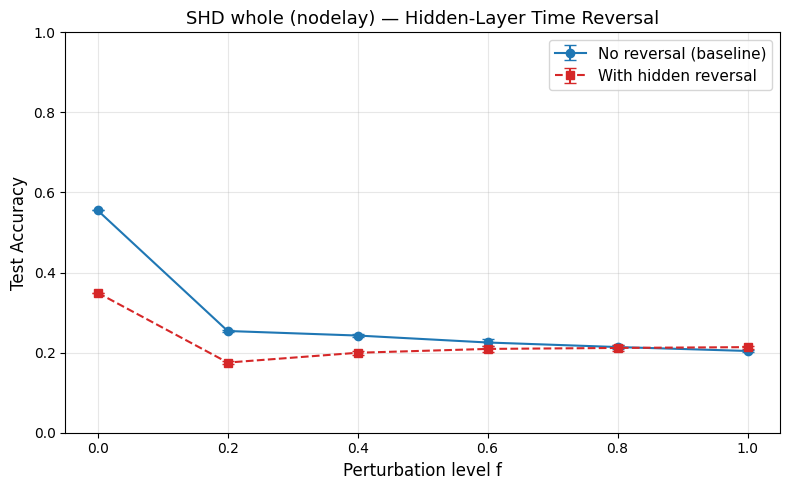

In [26]:
def plot_reversal_comparison(
    results: dict[str, dict[float, dict]],
) -> None:
    """Plot accuracy vs f for no-reversal and reversal conditions."""
    fig, ax = plt.subplots(figsize=(8, 5))

    # No reversal
    f_vals = sorted(results["no_reversal"].keys())
    means_nr = [results["no_reversal"][f]["mean"] for f in f_vals]
    stds_nr = [results["no_reversal"][f]["std"] for f in f_vals]

    ax.errorbar(
        f_vals, means_nr, yerr=stds_nr,
        fmt="o-", capsize=4, label="No reversal (baseline)",
        color="tab:blue",
    )

    # With reversal
    f_vals_r = sorted(results["reversal"].keys())
    means_r = [results["reversal"][f]["mean"] for f in f_vals_r]
    stds_r = [results["reversal"][f]["std"] for f in f_vals_r]

    ax.errorbar(
        f_vals_r, means_r, yerr=stds_r,
        fmt="s--", capsize=4, label="With hidden reversal",
        color="tab:red",
    )

    ax.set_xlabel("Perturbation level f", fontsize=12)
    ax.set_ylabel("Test Accuracy", fontsize=12)
    ax.set_title(
        f"SHD {DATASET_KEY} ({DELAY_TAG}) — Hidden-Layer Time Reversal",
        fontsize=13,
    )
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0, 1)

    plt.tight_layout()

    os.makedirs("log", exist_ok=True)
    fig_path = f"log/{MODEL_PREFIX}_reversal_sweep.png"
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Figure saved to {fig_path}")

    plt.show()


plot_reversal_comparison(sweep_results)

## 13. Save Results

Save the sweep results to JSON for later comparison across dataset
variants and delay/no-delay modes.

In [27]:
# Convert results to JSON-serialisable format
results_serialisable = {}
for condition, cond_results in sweep_results.items():
    results_serialisable[condition] = {
        str(f_val): {
            "mean": float(data["mean"]),
            "std": float(data["std"]),
            "values": [float(v) for v in data["values"]],
        }
        for f_val, data in cond_results.items()
    }

os.makedirs("log", exist_ok=True)
results_path = f"log/{MODEL_PREFIX}_reversal_sweep_results.json"
with open(results_path, "w") as fp:
    json.dump(results_serialisable, fp, indent=2)
print(f"Results saved to {results_path}")

Results saved to log/shd_whole_nodelay_reversal_sweep_results.json


## 14. Model Analysis

Print delay statistics and weight statistics for the loaded model.

In [28]:
print(
    f"=== Learned Parameter Analysis "
    f"(SHD {DATASET_KEY}, {DELAY_TAG}) ==="
)

# Delay statistics
delays = net.get_delays()
if delays:
    for delay_name, delay_values in delays.items():
        if len(delay_values) > 0:
            print(
                f"Learned {delay_name}: "
                f"mean={np.mean(delay_values):.2f}, "
                f"std={np.std(delay_values):.2f}, "
                f"min={np.min(delay_values):.2f}, "
                f"max={np.max(delay_values):.2f}"
            )
else:
    print("No delays (SGD mode)")

# Weight statistics per layer
for name, param in net.named_parameters():
    if "weight" in name:
        w = param.data
        print(
            f"{name}: mean={w.mean().item():.4f}, "
            f"std={w.std().item():.4f}, "
            f"shape={list(w.shape)}"
        )

=== Learned Parameter Analysis (SHD whole, nodelay) ===
No delays (SGD mode)
fc1.weight_g: mean=39.7592, std=28.4301, shape=[128, 1, 1, 1, 1]
fc1.weight_v: mean=-0.8521, std=10.7609, shape=[128, 700, 1, 1, 1]
fc2.weight_g: mean=53.7688, std=66.7980, shape=[128, 1, 1, 1, 1]
fc2.weight_v: mean=-0.2353, std=6.3544, shape=[128, 128, 1, 1, 1]
fc3.weight_g: mean=197.5736, std=40.3379, shape=[20, 1, 1, 1, 1]
fc3.weight_v: mean=-0.4522, std=7.4275, shape=[20, 128, 1, 1, 1]
